In [ ]:
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
data = {
    'CGPA': [5.5, 6.0, 6.2, 6.5, 6.8, 7.0, 7.2, 7.5, 7.8, 8.0,
             8.2, 8.5, 8.7, 9.0, 9.2],

    'Package': [2.5, 2.8, 3.0, 3.2, 3.5, 3.8, 4.0, 4.3, 4.6, 4.8,
                5.0, 5.5, 5.8, 6.2, 6.5]
}
df = pd.DataFrame(data)

In [ ]:
print("First 5 rows:")
print(df.head())

First 5 rows:
   CGPA  Package
0   5.5      2.5
1   6.0      2.8
2   6.2      3.0
3   6.5      3.2
4   6.8      3.5


In [ ]:
print("\nDataset shape:")
print(df.shape)


Dataset shape:
(15, 2)


In [ ]:
print("\nDataset information:")
df.info()


Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CGPA     15 non-null     float64
 1   Package  15 non-null     float64
dtypes: float64(2)
memory usage: 372.0 bytes


In [ ]:
print("\nStatistical summary:")
print(df.describe())
print(df.isnull().sum())


Statistical summary:
            CGPA    Package
count  15.000000  15.000000
mean    7.473333   4.366667
std     1.139214   1.261330
min     5.500000   2.500000
25%     6.650000   3.350000
50%     7.500000   4.300000
75%     8.350000   5.250000
max     9.200000   6.500000
CGPA       0
Package    0
dtype: int64


In [ ]:
X = df[['CGPA']]
y = df['Package']

In [ ]:
print("Independent Variable (X): CGPA")
print("Dependent Variable (y): Package")

Independent Variable (X): CGPA
Dependent Variable (y): Package


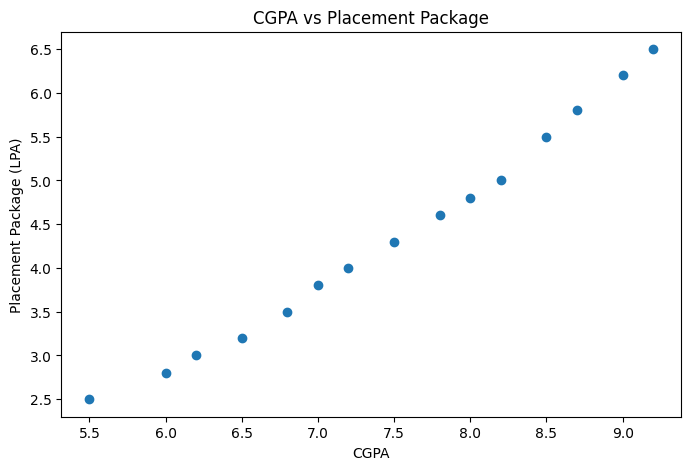

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.scatter(X, y)
plt.xlabel("CGPA")
plt.ylabel("Placement Package (LPA)")
plt.title("CGPA vs Placement Package")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)
print("Training data:")
print(X_train)
print("\nTesting data:")
print(X_test)

Training data:
    CGPA
13   9.0
5    7.0
8    7.8
2    6.2
1    6.0
14   9.2
4    6.8
7    7.5
10   8.2
12   8.7
3    6.5
6    7.2

Testing data:
    CGPA
9    8.0
11   8.5
0    5.5


In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

In [ ]:
model.fit(X_train, y_train)
print("Model training completed.")
print("Slope (β1):", model.coef_[0])
print("Intercept (β0):", model.intercept_)

Model training completed.
Slope (β1): 1.1524975829842095
Intercept (β0): -4.261669352239774


In [ ]:
y_pred = model.predict(X_test)
print("Actual values:")
print(y_test.values)
print("\nPredicted values:")
print(y_pred)
comparison = pd.DataFrame({
    'CGPA': X_test['CGPA'].values,
    'Actual Package': y_test.values,
    'Predicted Package': y_pred
})

Actual values:
[4.8 5.5 2.5]

Predicted values:
[4.95831131 5.5345601  2.07706735]


In [ ]:
r2 = r2_score(y_test, y_pred)
print("R² Score:", r2)
print("R² Percentage:", r2 * 100, "%")
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)

R² Score: 0.9583635531071921
R² Percentage: 95.83635531071921 %
Mean Absolute Error: 0.20526802019551038
Mean Squared Error: 0.06837629834174448


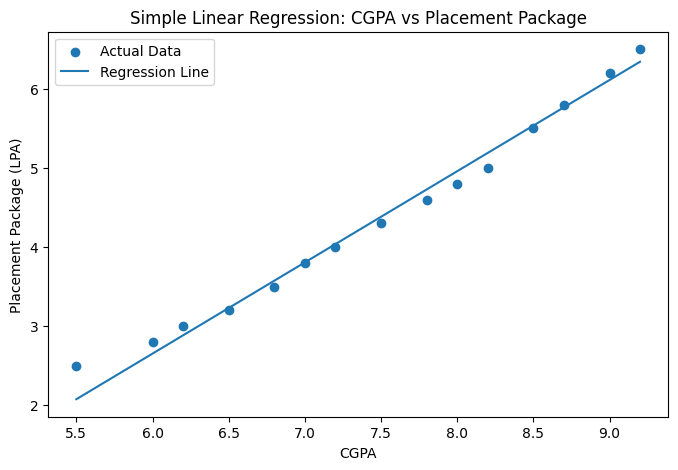

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(X, y, label="Actual Data")
plt.plot(X, model.predict(X), label="Regression Line")
plt.xlabel("CGPA")
plt.ylabel("Placement Package (LPA)")
plt.title("Simple Linear Regression: CGPA vs Placement Package")
plt.legend()
plt.show()

In [ ]:
new_cgpa = [[8.5]]
predicted_package = model.predict(new_cgpa)
print("CGPA:", new_cgpa[0][0])
print("Predicted Placement Package:", predicted_package[0], "LPA")

CGPA: 8.5
Predicted Placement Package: 5.534560103126007 LPA


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
new_students = [[7.0], [8.0], [8.5], [9.0], [9.5]]
predicted_packages = model.predict(new_students)
for cgpa, package in zip(new_students, predicted_packages):
    print(f"CGPA: {cgpa[0]} -> Predicted Package: {package:.2f} LPA")

CGPA: 7.0 -> Predicted Package: 3.81 LPA
CGPA: 8.0 -> Predicted Package: 4.96 LPA
CGPA: 8.5 -> Predicted Package: 5.53 LPA
CGPA: 9.0 -> Predicted Package: 6.11 LPA
CGPA: 9.5 -> Predicted Package: 6.69 LPA


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
